In [1]:
import os
from runpy import run_path
import torch
import spikeextractors as se
import spikeinterface.full as si
import matplotlib
import torch, cv2, os, sys, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import mean_squared_error
from LAM.SaliencyModel.BackProp import saliency_map_PG as saliency_map
from LAM.SaliencyModel.BackProp import attribution_objective, GaussianBlurPath, LinearPath, Path_gradient
from LAM.SaliencyModel.attributes import attr_grad, attr_id,attr_id_abs
from LAM.SaliencyModel.utils import grad_abs_norm, vis_saliency, gini, make_pil_grid
from LAM.utils import get_closest_channels, plot_intp_image, plot_magnitude_of_gradient, plot_target
from res_utils import Generate
import gc


plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 8 # 设置全局字体大小

# 设置color
main_color = '#233342'
good_color = '#6A8F95'
bad_color = '#B8A49D'
# di_color = '#B78C7C'
di_color= '#BAD2D3'
cmap = LinearSegmentedColormap.from_list('custom', [(0, 'white'), (1, 'red')])

/root/miniconda3/envs/spk_res/lib/python3.9/site-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [2]:
# recording
dtpath = '/root/autodl-tmp/real_dataset'
nwb_real_rec = os.path.join(dtpath,'sub-mouse412804_ecephys.nwb')
nwb_real_sorter1 = os.path.join(dtpath,'sub-mouse412804_ses-20200824T155542.nwb')
nwb_real_sorter2 = os.path.join(dtpath,'sub-mouse412804_ses-20200824T155543.nwb')
rec = si.read_nwb(nwb_real_rec,load_recording=True)
sampling_frequency = rec.sampling_frequency
manual_sorter1 = se.NwbSortingExtractor(nwb_real_sorter1, sampling_frequency=sampling_frequency)  # 人工sorter1
manual_sorter2 = se.NwbSortingExtractor(nwb_real_sorter2, sampling_frequency=sampling_frequency)  # 人工sorter2

/root/miniconda3/envs/spk_res/lib/python3.9/site-packages/hdmf/utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.2.0 because version 1.8.0 is already loaded.
  return func(args[0], **pargs)
/root/miniconda3/envs/spk_res/lib/python3.9/site-packages/hdmf/utils.py:668: UserWarning: Ignoring cached namespace 'core' version 2.2.5 because version 2.7.0 is already loaded.
  return func(args[0], **pargs)


In [3]:
method = 'SpkRes'
factor_list = [16,8,4,2]
# factor_list = [2]
atrr_method = 'id'  # grad / id
path_method = 'line'  # gaussian / line
# sigma = 2.2 ; fold = 50 ; l = 9 ; alpha = 0.5
sigma = 5 ; fold = 50 ; l = 100 ; alpha = 0.5
# 存在spike的range
frame_range = [150,398] 
gt = rec.get_traces(start_frame=frame_range[0], end_frame=frame_range[1])
# 根据最小值 选择w和h
# gt_min = np.unravel_index(gt.argmin(), gt.shape)
gt_min = [70,81]

w = gt_min[1] # 电极通道
h = gt_min[0] # 采样点
window_w = 1 # 电极通道
window_h = 50 # 采样点

In [ ]:
###################### model ######################
opt_path = 'options_linux/rec248/Reconstrcution_{}.yml'.format(method)  # SpkRecon / SwinIR
generate = Generate(opt_path)
model = generate.generate_model()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

/root/miniconda3/envs/spk_res/lib/python3.9/site-packages/spikeinterface/core/baserecordingsnippets.py:244: UserWarning: There is no Probe attached to this recording. Creating a dummy one with contact positions
  warn("There is no Probe attached to this recording. Creating a dummy one with contact positions")


The DI of this case is 22.912302595219924
The DI of this case is 17.956613730479386
The DI of this case is 13.945063524650847
The DI of this case is 21.871254191392953


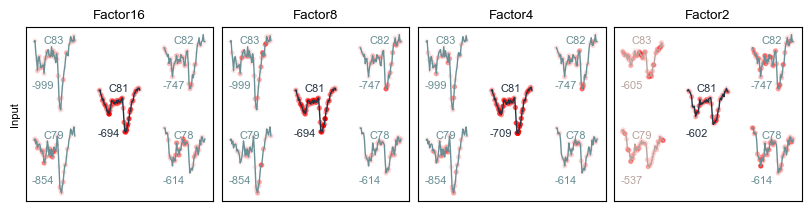

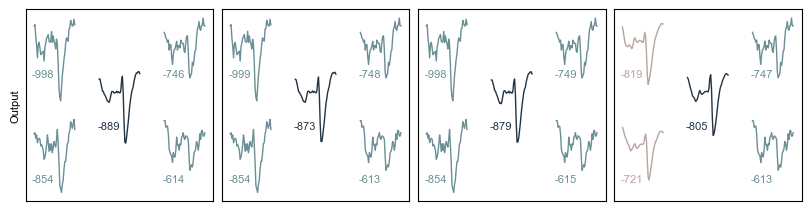

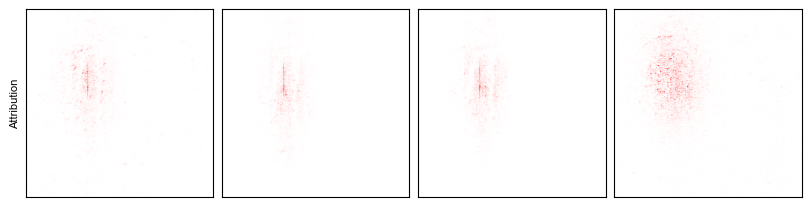

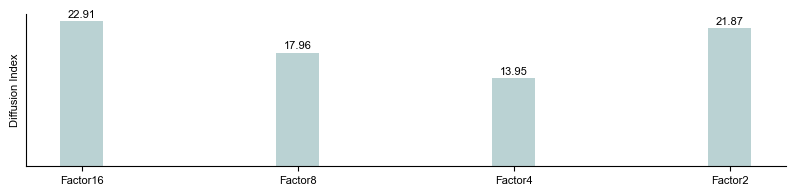

In [5]:
# 找出相邻通道
mcl = w # 主通道
neigh_chls = get_closest_channels(rec,num_channels=4)[0][mcl]
neigh_chls_dist = get_closest_channels(rec,num_channels=4)[1][mcl]
locations = rec.get_channel_locations(channel_ids=neigh_chls)
locations = locations-locations[0]
slt_gt = gt[h: h + window_h, neigh_chls]  # gt

grad_pil_list,di_list = [],[]
xs = np.linspace(-5, 5, fold)
fig_input, axes_input = plt.subplots(1, len(factor_list), figsize=(len(factor_list) * 2, 2), constrained_layout=True, sharey=True)
fig_output, axes_output = plt.subplots(1, len(factor_list), figsize=(len(factor_list) * 2, 2), constrained_layout=True, sharey=True)
fig_weight, axes_weight = plt.subplots(1, len(factor_list), figsize=(len(factor_list) * 2, 2), constrained_layout=True, sharey=True)

for fi,factor in enumerate(factor_list):
    # weights = os.path.join('weights/lam_method/{}/net_g_factor{}.pth'.format(method,factor))  # 网络模型权重
    weights = os.path.join('weights/rec248/{}/net_g_factor{}.pth'.format(method,factor))  # 网络模型权重
    checkpoint = torch.load(weights)
    model.load_state_dict(checkpoint['params'])
    model.eval()

    channel_ids = rec.channel_ids
    bad_chans = channel_ids[channel_ids % factor == 1]
    good_chans = channel_ids[~np.isin(channel_ids, bad_chans)]
    window = len(channel_ids)

    # 1. kriging插值
    krig_weights = None
    krig_rec = si.interpolate_bad_channels(rec, bad_chans, weights=krig_weights)

    # 选择合适的spikes信号
    lq_krig = krig_rec.get_traces(start_frame=frame_range[0], end_frame=frame_range[1])
    test_lq = lq_krig
    lq_krig = np.expand_dims(lq_krig, axis=2)
    lq_krig = torch.from_numpy(lq_krig).float().permute(2, 0, 1).unsqueeze(0).to(device)

    img_lr = lq_krig

    # # 放入model中
    intp_trace = model(img_lr)
    test = intp_trace.detach().cpu().squeeze().numpy().astype(int)
    
    tensor_lr = img_lr.cpu().squeeze(1)

    # 归因方法
    if atrr_method == 'grad':
        attr_objective = attribution_objective(attr_grad, h, w, window_h=window_h,window_w=window_w) # 求梯度，找出像素值变化剧烈的点
    else:
        attr_objective = attribution_objective(attr_id, h, w, window_h=window_h,window_w=window_w) # 求和
        # attr_objective = attribution_objective(attr_id_abs, h, w, window_h=window_h,window_w=window_w) # 求和+abs
        

    # 插值路径：高斯模糊路径可能更合适
    if path_method == 'gaussian':
        gaus_blur_path_func = GaussianBlurPath(sigma, fold, l) # 高斯模糊路径
    else:
        gaus_blur_path_func = LinearPath(fold) # 线性插值，baseline为0
    interpolated_grad_numpy, result_numpy, interpolated_numpy,target_numpy,lambda_derivative_interpolation,grad_list = Path_gradient(tensor_lr.numpy(), model, attr_objective, gaus_blur_path_func, cuda=True)

    grad_numpy, result = saliency_map(interpolated_grad_numpy, result_numpy)
    abs_normed_grad_numpy = grad_abs_norm(grad_numpy)
    
    attr_path = os.path.join('LAM_results','results_{}_{}'.format(atrr_method,path_method))
    if not os.path.exists(attr_path):
        os.makedirs(attr_path)

    # save path
    save_fig_path = os.path.join(attr_path,'factor{}'.format(factor))
    if not os.path.exists(save_fig_path):
        os.makedirs(save_fig_path)

    # DI index
    gini_index = gini(abs_normed_grad_numpy)
    diffusion_index = (1 - gini_index) * 100
    print(f"The DI of this case is {diffusion_index}")
    di_list.append(np.round(diffusion_index,2))

    slt_grad = abs_normed_grad_numpy[h: h + window_h, neigh_chls]
    slt_lq = lq_krig.detach().cpu().numpy().squeeze()[h: h + window_h, neigh_chls] # lq
    slt_result = result.squeeze()[h: h + window_h, neigh_chls] # output
    
    
    # sigma临近0的时候，kernel会变成1
    slt_index = np.linspace(0, fold - 1, 5).astype(int) # 选择5个
    slt_intp = interpolated_numpy.squeeze()[slt_index][:, h: h + window_h, neigh_chls]

#     # 1. 证明LAM的有效性
#     # (1) 输入信号
#     fig_intp = plot_intp_image(slt_intp, neigh_chls, mcl, bad_chans, figsize=(5.2, 1.5), need_color=True)
#     fig_intp.savefig(os.path.join(save_fig_path, 'intp_wfs.tiff'), dpi=1800)
    
#     # (2) 输出信号

#     # (2) target
#     fig_target = plot_target(target_numpy)
#     fig_target.savefig(os.path.join(save_fig_path, 'target.tiff'), dpi=1800)

#     # (3) magnitude of gradient: 基于一阶微分算子计算梯度幅值
#     fig_mg = plot_magnitude_of_gradient(lambda_derivative_interpolation, fold)
#     fig_mg.savefig(os.path.join(save_fig_path, 'magnitude_of_gradient.tiff'), dpi=1800)
#     plt.show()

#     # (5) 不同输入的梯度
#     pil_list = []
#     for sli in slt_index:
#         # grad_i = interpolated_grad_numpy[:sli + 1]  # 积分因子
#         # grad_mean_i = grad_i.mean(axis=0)
#         # abs_normed_grad_i = grad_abs_norm(grad_mean_i)
#         grad_i = grad_list[sli]
#         abs_normed_grad_i = grad_abs_norm(grad_i) # 绝对值+归一化
#         saliency_image_abs_i = vis_saliency(abs_normed_grad_i, zoomin=1)
#         pil_list.append(saliency_image_abs_i)
#     pil = make_pil_grid(pil_list)
#     pil.info['dpi'] = 1800
#     pil.save(os.path.join(save_fig_path, 'grad_list.tiff'))
#     pil.show()
    
    # slt_index = [slt_index[-1]]
    # fig_weight_sigma,axes_weight_sigma = plt.subplots(1, len(slt_index), figsize=(len(slt_index) * 2, 2), constrained_layout=True, sharey=True)
    # axes_weight_sigma = [axes_weight_sigma]
    # for j,sli in enumerate(slt_index):
    #     grad_i = interpolated_grad_numpy[:sli + 1]  # 积分因子
    #     grad_mean_i = grad_i.mean(axis=0)
    #     abs_normed_grad_i = grad_abs_norm(grad_mean_i)
    #     axes_weight_sigma[j].imshow(abs_normed_grad_i,cmap=cmap,vmin=0,vmax=1)
    #     axes_weight_sigma[j].set_xticks([])
    #     axes_weight_sigma[j].set_yticks([])
    # fig_weight_sigma.savefig(os.path.join(save_fig_path, 'grad.tiff'), dpi=1800)
    # plt.show()
    
   # 2.分析模型：input / output / attribution / DI
    axes_weight[fi].imshow(abs_normed_grad_numpy,cmap=cmap,vmin=0,vmax=1)
    for i, wfs_i in enumerate(slt_lq.T):  # 输入数据
        chl_i = neigh_chls[i]
        if chl_i == mcl:
            color = main_color  # 需要插值的通道
        elif np.isin(chl_i, bad_chans):
            color = bad_color  # 坏通道
        else:
            color = good_color  # 好通道
            
        # 波形
        wfs_j = slt_result.T[i]
        axes_input[fi].plot(locations[i][0] + xs, locations[i][1] + wfs_i * 0.035 + 12, color=color,linewidth=1)
        axes_output[fi].plot(locations[i][0] + xs, locations[i][1] + wfs_j * 0.035 + 12, color=color,linewidth=1)

        # 电极
        # axes_input[fi].scatter(locations[i][0], locations[i][1]+2, s=10, marker='s', color=color)
        axes_input[fi].annotate('C{}'.format(neigh_chls[i]), (locations[i][0]-2.8, locations[i][1] + 5), color=color)

        # 积分因子
        grad_i = slt_grad[:, i]
        axes_input[fi].scatter(locations[i][0] + xs, locations[i][1] + wfs_i * 0.035 + 12, s=8, marker='o', color='red',alpha=grad_i)

        # 标注振幅
        axes_input[fi].annotate(int(np.min(wfs_i)), (locations[i][0] - 5.5, locations[i][1] - 14), color=color)
        axes_output[fi].annotate(int(np.min(wfs_j)), (locations[i][0] - 5.5, locations[i][1] - 14), color=color)

    # 隐藏 x 轴和 y 轴的刻度
    axes_input[fi].set_xticks([])
    axes_input[fi].set_yticks([])
    axes_input[fi].set_title('Factor{}'.format(factor))

    # 隐藏 x 轴和 y 轴的刻度
    axes_output[fi].set_xticks([])
    axes_output[fi].set_yticks([])
    # axes_output[fi].set_title('Factor{}'.format(factor), fontname='Arial', fontsize=8)

    axes_weight[fi].set_xticks([])
    axes_weight[fi].set_yticks([])

# 设置label
axes_input[0].set_ylabel('Input')
axes_output[0].set_ylabel('Output')
axes_weight[0].set_ylabel('Attribution')

# 1. 输入图
# fig_input.savefig(os.path.join(attr_path,'input_all_factors.tiff'),dpi=1800)
# 2. 输出图
# fig_output.savefig(os.path.join(attr_path,'output_all_factors.tiff'),dpi=1800)
# 3. 权重图
# fig_weight.savefig(os.path.join(attr_path,'weight_all_factors.tiff'),dpi=1800)
# 4. DI index
labels = ['Factor16','Factor8','Factor4','Factor2']
fig,ax = plt.subplots(1,1,figsize=(len(factor_list) * 2, 2))
ax.bar(labels,di_list,width=0.2,color=di_color)
for i,dii in enumerate(di_list):
        ax.text(i,di_list[i]+0.2,str(dii),ha='center', va='bottom', fontsize=8)
ax.set_yticks([])
ax.set_ylabel('Diffusion Index')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
# fig.savefig(os.path.join(attr_path,'DI_bar.tiff'),dpi=1800)
plt.show()